**📌 Problem**

Which customers are likely to leave?

**Why it’s valuable:** Used in real businesses; combines classification with business value.


In [30]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
os.chdir('/content/drive/My Drive/ml-portfolio/Project3')

Mounted at /content/drive


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

print('✅ All libraries loaded successfully')

✅ All libraries loaded successfully


In [32]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.shape

(7043, 21)

**Context**
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs."

**Content**
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

***The data set includes information about:***

* Customers who left within the last month – the column is called Churn
* Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
* Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
* Demographic info about customers – gender, age range, and if they have partners and dependents

#Exploratory Data Analysis (EDA)

In [33]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [35]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [36]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [37]:
df.groupby('Contract')['Churn'].value_counts()

Contract        Churn
Month-to-month  No       2220
                Yes      1655
One year        No       1307
                Yes       166
Two year        No       1647
                Yes        48
Name: count, dtype: int64

In [38]:
df.groupby('tenure')['Churn'].value_counts()

tenure  Churn
0       No        11
1       Yes      380
        No       233
2       Yes      123
        No       115
                ... 
70      Yes       11
71      No       164
        Yes        6
72      No       356
        Yes        6
Name: count, Length: 145, dtype: int64

In [39]:
df.groupby('MonthlyCharges')['Churn'].value_counts()

,,count
MonthlyCharges,Churn,
18.25,No,1
18.40,No,1
18.55,No,1
18.70,No,2
18.75,No,1
...,...,...
118.20,No,1
118.35,Yes,1
118.60,No,2


#Data Preprocessing

In [40]:
df = df.drop("customerID", axis=1)

In [41]:
df["TotalCharges"]

,TotalCharges
0,29.85
1,1889.5
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.5
7039,7362.9
7040,346.45
7041,306.6


In [42]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [43]:
df["TotalCharges"]

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [44]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [45]:
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

In [46]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

In [47]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [49]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

#Feature Engineering

In [50]:
X = pd.get_dummies(X, drop_first=True)

**One-Hot Encoding (Important)**

Most columns are categorical.

In [51]:
X.shape

(7043, 30)

#Model Training & Comparison

##Prepare Data

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

stratify=y ensures class balance preserved.

Very important in classification.

In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Scaling (For Logistic Regression)

Random Forest does NOT require scaling.

Logistic Regression does.

##MODEL 1 — Logistic Regression

In [54]:
log_model = LogisticRegression(max_iter=5000)
log_model.fit(X_train_scaled, y_train)

print("Train Accuracy:", log_model.score(X_train_scaled, y_train))
print("Test Accuracy:", log_model.score(X_test_scaled, y_test))

Train Accuracy: 0.8059992900248492
Test Accuracy: 0.8069552874378992


###Evaluate Logistic Regression

[[925 110]
 [162 212]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8415846443979436


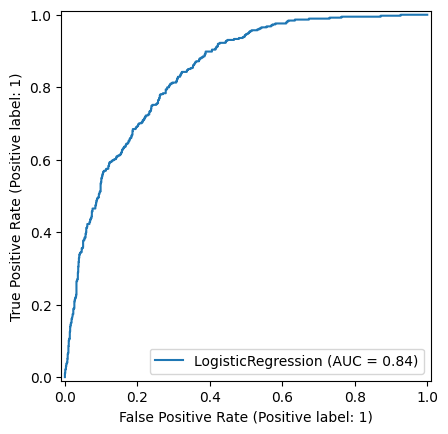

In [55]:
y_pred_log = log_model.predict(X_test_scaled)

print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

RocCurveDisplay.from_estimator(log_model, X_test_scaled, y_test)
plt.show()

##MODEL 2 — Random Forest

In [56]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 0.9980475683351083
Test Accuracy: 0.7899219304471257


###Evaluate Random Forest

[[926 109]
 [187 187]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.8269691802939886


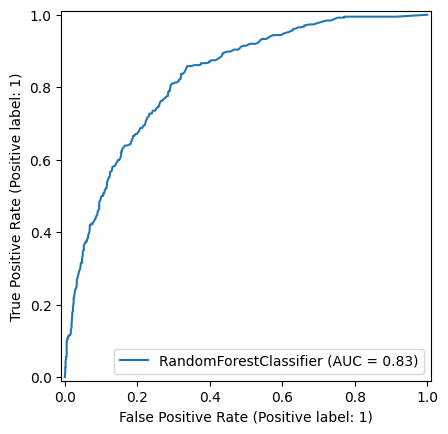

In [57]:
y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

#Conclusion

**Observation1:** Overfitting Check

**🔵 Logistic Regression**

* Train Accuracy ≈ 0.806

* Test Accuracy ≈ 0.807

* Gap ≈ 0.001

✅ Very stable
✅ Low variance
✅ No overfitting

**🌲 Random Forest**

* Train Accuracy ≈ 0.998

* Test Accuracy ≈ 0.790

* Gap ≈ 0.208

🚨 Massive gap
🚨 Very high variance
🚨 Clear overfitting

Because:

* max_depth=None

* 300 trees

* Fully grown trees memorize training data

**Observation2:** ROC-AUC Comparison

Logistic: 0.842

Random Forest: 0.827

👉 Logistic is better at ranking churn probability.

This is important in business — ranking matters more than raw accuracy.

So currently:

🏆 Logistic Regression wins.

**Observation3:** Confusion Matrix Analysis

**Logistic**

[[925 110]

 [162 212]]

***Meaning:***

TN = 925

FP = 110

FN = 162

TP = 212

Churners correctly identified: **212**

Churners missed: **162**

**Random Forest**

[[926 109]

 [187 187]]

 ***Meaning:***

TN = 926

FP = 109

FN = 187

TP = 187

Churners correctly identified: **187**

Churners missed: **187**

Random Forest misses more churners.

**🧠 Business Thinking**

In churn prediction:

❓ What is worse?

False Positive (predict churn but they stay)

False Negative (predict stay but they churn)

Answer:

🚨 False Negative is worse.

Because:

* That customer leaves

* Revenue lost

* No retention attempt made

Logistic FN = 162

Random Forest FN = 187

👉 Logistic misses fewer churners.

#Final Conclusion (Current Model)

**Metric** -	**Winner**

Overfitting - 	Logistic

ROC-AUC -	Logistic

FN (business critical) -	Logistic

Stability -	Logistic

🏆 Logistic Regression is currently better.

Accuracy is ~80%.

But churn class is imbalanced (~26% churn rate).[ 374/1409 = 26% ]

Accuracy is misleading.

Should focus on:

* Recall (churn class)

* ROC-AUC

* Precision-Recall tradeoff

#**Threshold Tuning**

Right now threshold = 0.5

What if we reduce threshold to 0.35?

We may:

* Catch more churners

* Increase recall

* Reduce FN

* But increase FP

In [58]:
threshold = 0.35

y_pred_custom = (y_prob_log >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[813 222]
 [109 265]]
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1035
           1       0.54      0.71      0.62       374

    accuracy                           0.77      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.77      0.77      1409



##Compare Before vs After Threshold Change

Original (Threshold = 0.5)

* FN = 162

* TP = 212

* Recall = 212 / (212 + 162) ≈ 0.57

New (Threshold = 0.35)

* FN = 109

* TP = 265

* Recall = 265 / (265 + 109) ≈ 0.71

🚀 Recall improved from 57% → 71%

That’s huge.

🧠 What Just Happened?

By lowering threshold:

Made model more “sensitive”.

It now flags more customers as churners.

So:

* Fewer churners missed ✅

* More customers targeted for retention ✅

* Probably more False Positives ❗

But in churn problems, that is acceptable.

##Business Interpretation

Let’s think like a company.

Suppose:

* Each lost customer = ₹10,000 lifetime value

* Cost of retention campaign per flagged customer = ₹500

Original model:

* Missed 162 churners → ₹16,20,000 lost

New model:

* Missed 109 churners → ₹10,90,000 lost

Saved revenue difference:
₹5,30,000 improvement

🎯 Key Insight

Accuracy barely changed.

But business impact changed massively.

This is why:

Accuracy ≠ Business performance.

#So far we have seen:


* Probability output is more powerful than prediction

* Threshold tuning > model switching

* Logistic Regression can beat Random Forest

* Overfitting doesn't mean better business model

* Recall matters more in churn

#Now Let’s Improve Random Forest Properly

We will control complexity.

In [59]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42
)

In [60]:
rf_model.fit(X_train, y_train)

print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))

Train Accuracy: 0.8251686190983316
Test Accuracy: 0.8041163946061036


##Evaluate

[[948  87]
 [189 185]]
              precision    recall  f1-score   support

           0       0.83      0.92      0.87      1035
           1       0.68      0.49      0.57       374

    accuracy                           0.80      1409
   macro avg       0.76      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

ROC-AUC: 0.843793433051745


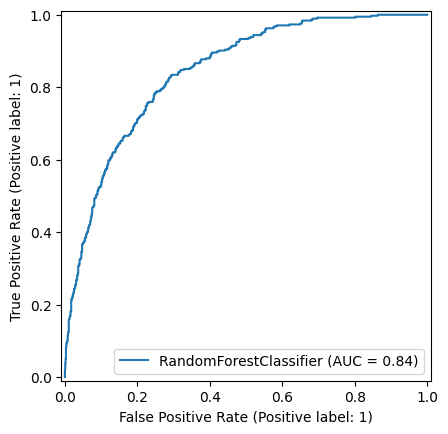

In [61]:
y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)
plt.show()

##Controlled Random Forest Results

* Train Accuracy: 0.825

* Test Accuracy: 0.804

* ROC-AUC: 0.844

* FN: 189

* TP: 185

**🧠 Step 1 — Overfitting Check**

Train = 82.5%

Test = 80.4%

Gap ≈ 2%

✅ Overfitting mostly controlled

Huge improvement from 99.8% train earlier.

Good tuning.

**🧠 Step 2 — ROC-AUC Comparison**

**Model** - **ROC-AUC**

Logistic (0.5 threshold) -	0.842

Tuned RF -	0.844

Now Random Forest slightly wins in ranking ability.

This means:

👉 RF is slightly better at ordering customers by churn probability.

**🧠 Step 3 — The Critical Metric (Recall / FN**)

For churn, FN is dangerous.

Tuned RF:

FN = 189

TP = 185

Recall = 185 / (185 + 189) ≈ 0.49

🚨 That is worse than original logistic (0.57 recall).

So even though RF has slightly better ROC-AUC,
it catches fewer churners at threshold = 0.5.

**🎯 What This Means**

Random Forest is:

* Slightly better at probability ranking

* More conservative at default threshold

* Missing more churners

Logistic (after threshold tuning to 0.35) was:

* Recall ≈ 0.71

* FN = 109

That is dramatically better from business view.

**🔥 Important Insight**

A model can have:

Better ROC-AUC

But worse recall at a chosen threshold




ROC-AUC measures ranking quality.

Threshold decides business outcome.

💡 The Real Question Now

Instead of asking:

Which model is better?

We ask:

Which model gives best business impact after threshold tuning?

So now we do same threshold tuning for Random Forest.

In [62]:
threshold = 0.35

y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf_custom = (y_prob_rf >= threshold).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_rf_custom))
print(classification_report(y_test, y_pred_rf_custom))

[[824 211]
 [106 268]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.78      0.78      1409



**📊 Tuned Random Forest @ Threshold = 0.35**

* FN = 106

* TP = 268

Recall = 268 / (268 + 106) ≈ 0.72

**🔥 Compare With Logistic @ 0.35**

Model	- FN	- TP	- Recall

Logistic -	109	- 265- 0.71

Tuned - RF	- 106	- 268	- 0.72

👉 Tuned Random Forest slightly wins now.

**🧠 What Just Happened?**

At threshold 0.5:

* Logistic looked better.

After threshold tuning:

* Random Forest became slightly stronger.

This shows something very important:

Model comparison must be done at optimal threshold, not default 0.5.

**💼 Business Conclusion**

If goal is:

"Catch as many churners as possible"

Best current model:

**🏆 Tuned Random Forest with threshold = 0.35**

Because:

* Lowest FN

* Highest recall

* Good ROC-AUC

* Controlled overfitting

#Final Stage - Feature Importance

In [63]:
import pandas as pd

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importances.head(10))

tenure                             0.199488
TotalCharges                       0.143638
InternetService_Fiber optic        0.092464
MonthlyCharges                     0.086113
Contract_Two year                  0.080625
PaymentMethod_Electronic check     0.074629
OnlineSecurity_Yes                 0.041266
Contract_One year                  0.040886
TechSupport_Yes                    0.023376
TechSupport_No internet service    0.019942
dtype: float64


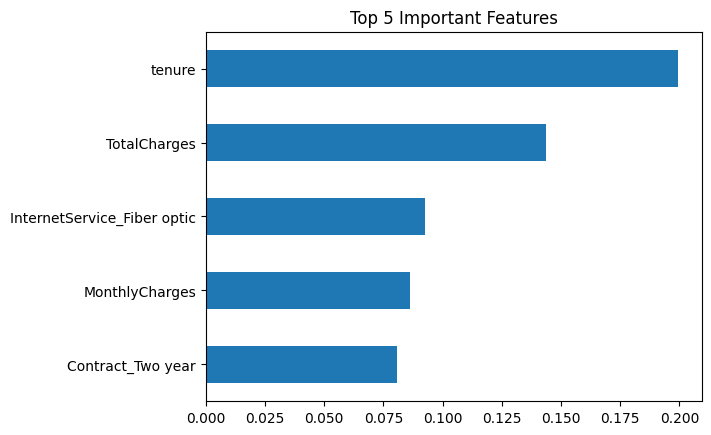

In [64]:
feature_importances.nlargest(5).sort_values().plot(kind="barh")
plt.title("Top 5 Important Features")
plt.show()

## Feature-by-Feature Business Meaning

1️⃣ **Tenure (Most Important)**

Longer tenure → Less churn
Short tenure → High churn

💡 Meaning:
New customers are risky.

📌 Business Action:

* Strong onboarding

* First 90-day retention program

* Early engagement emails

**2️⃣ TotalCharges**

High total spending → Lower churn

Customers who invested more stay longer.

💡 Meaning:
Customers build “commitment bias”.

📌 Business Action:

* Encourage bundled services

* Offer add-ons early

**3️⃣ InternetService_Fiber optic**

Fiber users churn more than DSL users in this dataset.

Possible reasons:

* Higher price

* Higher expectations

* Service complaints

📌 Business Action:

* Monitor fiber customer satisfaction

* Offer loyalty perks

**4️⃣ MonthlyCharges**

Higher monthly charge → Higher churn probability.

💡 Meaning:
Price sensitivity matters.

📌 Business Action:

* Discount at-risk high-paying customers

* Offer contract lock-ins

**5️⃣ Contract_Two year**

Two-year contract strongly reduces churn.

💡 Meaning:
Commitment reduces churn.

📌 Business Action:

* Incentivize long-term contracts

* Offer discount for 24-month plan

**🎯 Final Business Summary**

Churn drivers in this dataset:

* Short tenure

* High monthly charges

* No long contract

* Fiber service

* Low accumulated spending